In [25]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import functions
from astropy.table import Table, vstack
import matplotlib.lines as mlines
import os
import emcee
from astropy.io import ascii
import corner
from timeit import default_timer as timer
import matplotlib.colors as colors
import matplotlib.cm as cmx
from scipy.optimize import least_squares, curve_fit
from scipy.stats import f

## Filepaths and Loading in Data

In [29]:
current_dir = os.getcwd()
SNe_csv_dir = '/Users/adeutsch/SN2018ivc_2026/comparison_data'

SN2001ig_csv = os.path.join(SNe_csv_dir, '01ig.csv')
SN1993j_csv = os.path.join(SNe_csv_dir, '93j.csv')
SN2011dh_csv = os.path.join(SNe_csv_dir, '11dh.csv')
SN1979c_csv = os.path.join(SNe_csv_dir, '79c.csv')

In [30]:
def load(sn_file, cols):
    t = Table.read(sn_file, format="csv")
    return t[cols]

cols = ["Date", "Time", "Tel", "Freq", "Flux (mJy)", "rms", "Lum", "Lum_Err", "nuLu", "nuLu_Err"]

SN2001ig  = load(SN2001ig_csv, cols)
SN1993j  = load(SN1993j_csv, cols)
SN2011dh  = load(SN2011dh_csv, cols)
SN1979c  = load(SN1979c_csv, cols)

In [31]:
# load in sn2001ig atca data from soria et al 2025
sn2001ig_atca_times = np.array([4199.1,4201.1,7064.2,7064.2,8101.4,8101.4,8167.2,8172.2,8172.2])
sn2001ig_atca_freqs = np.array([2.1,2.1,5.5,9.0,5.5,9.0,2.1,5.5,9.0])
sn2001ig_atca_fluxes = np.array([6.90,7.15,2.64,1.20,3.22,1.93,8.00,3.30,1.95])
sn2001ig_atca_rms = np.array([0.28,0.29,0.11,0.10,0.09,0.20,0.20,0.09,0.08])

In [37]:
# load in 18ivc data
SN2018ivc = Table.read('data/radio_18ivc_data.csv', format='csv')
SN2018ivc

phase,freq,flux,flux_err,telescope
float64,float64,float64,float64,str5
263.5,24.1,0.546,0.025,VLA
263.5,31.0,0.43,0.038,VLA
263.5,41.0,0.249,0.037,VLA
795.9,6.0,8.576,0.09,VLA
789.0,10.0,8.88,0.12,VLA
4.1,100.0,4.25,0.22,ALMA
7.1,100.0,7.42,0.38,ALMA
17.1,100.0,9.05,0.46,ALMA
21.0,93.5,7.41,0.99,ALMA


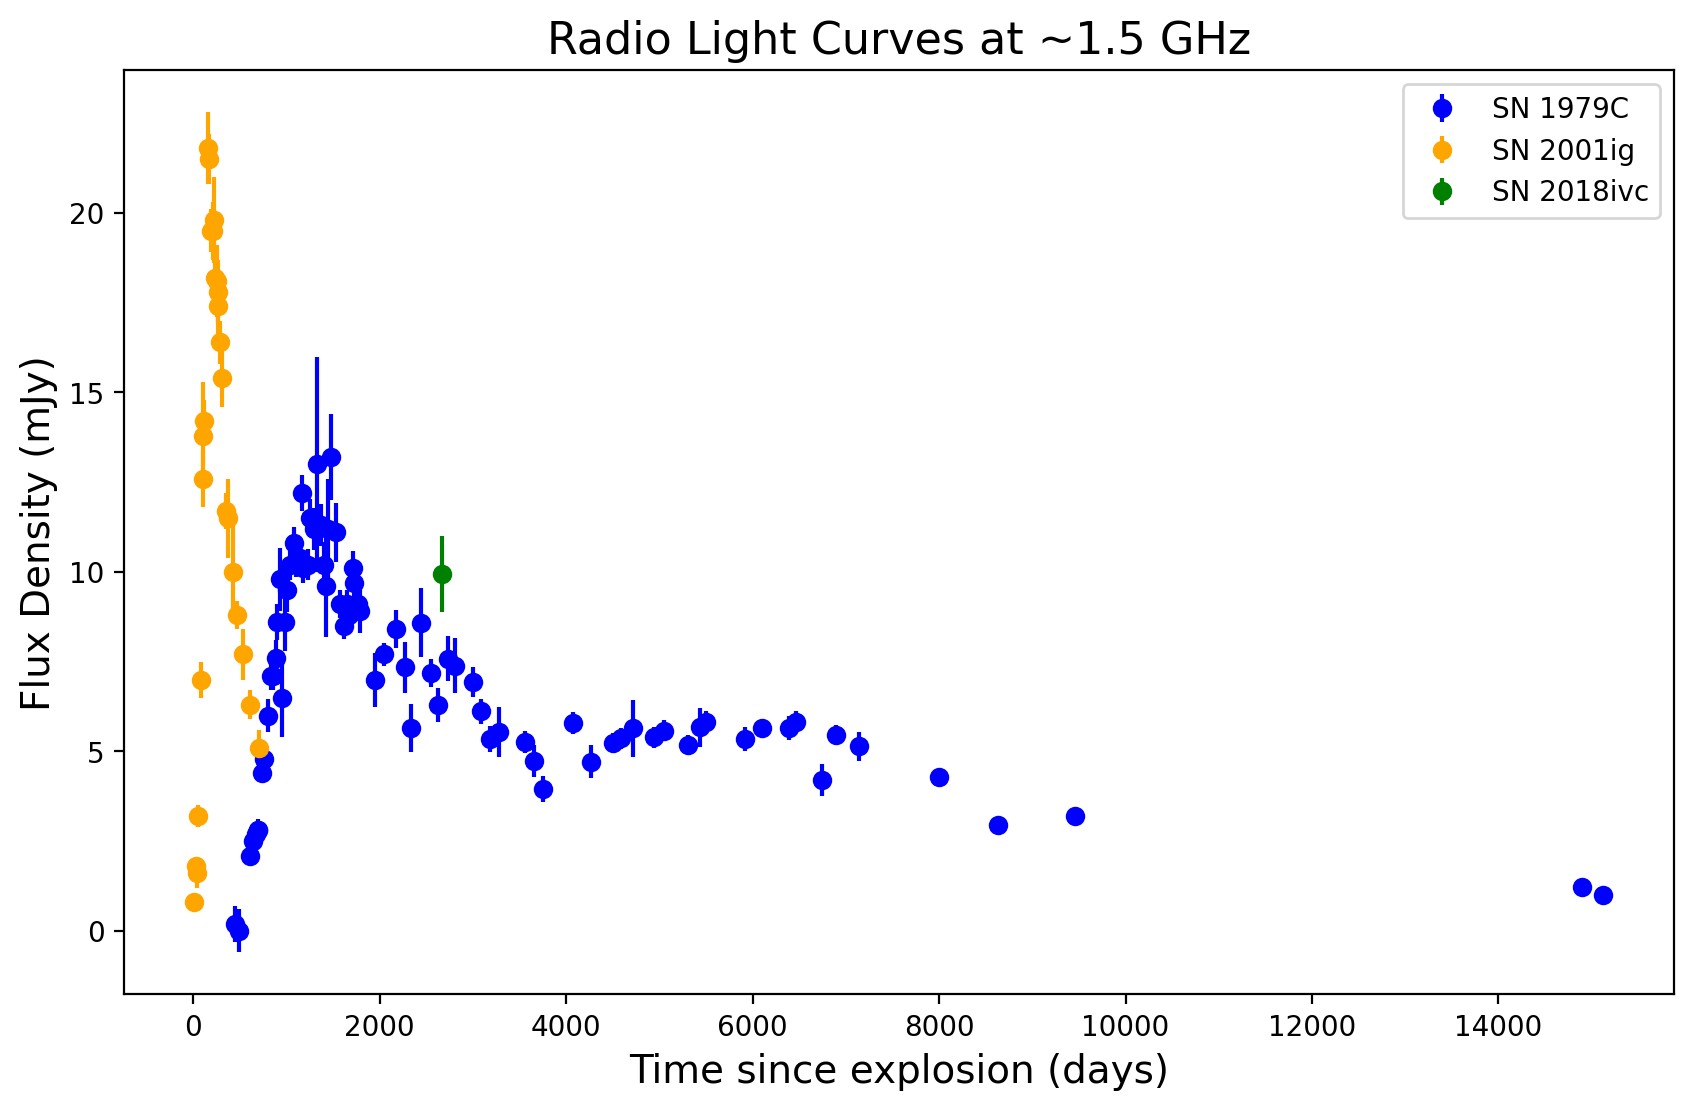

In [35]:
# plot IIL comparison at ~1.5 GHz
SN1979C_15 = SN1979c[((SN1979c['Freq'] > 1.0)&(SN1979c['Freq'] < 2.0))]
SN2001ig_15 = SN2001ig[((SN2001ig['Freq'] > 1.0)&(SN2001ig['Freq'] < 2.0))]
SN2018ivc_15 = SN2018ivc[((SN2018ivc['freq'] > 1.0)&(SN2018ivc['freq'] < 2.0))]

plt.figure(figsize=(10,6), dpi=200)
plt.errorbar(SN1979C_15['Time'], SN1979C_15['Flux (mJy)'], yerr=SN1979C_15['rms'], fmt='o', label='SN 1979C', color='blue')
plt.errorbar(SN2001ig_15['Time'], SN2001ig_15['Flux (mJy)'], yerr=SN2001ig_15['rms'], fmt='o', label='SN 2001ig', color='orange')
plt.errorbar(SN2018ivc_15['phase'], SN2018ivc_15['flux'], yerr=SN2018ivc_15['flux_err'], fmt='o', label='SN 2018ivc', color='green')
plt.xlabel('Time since explosion (days)', fontsize=14)
plt.ylabel('Flux Density (mJy)', fontsize=14)
plt.title('Radio Light Curves at ~1.5 GHz', fontsize=16)
plt.legend()

(-747.4852500000001, 3000.0)

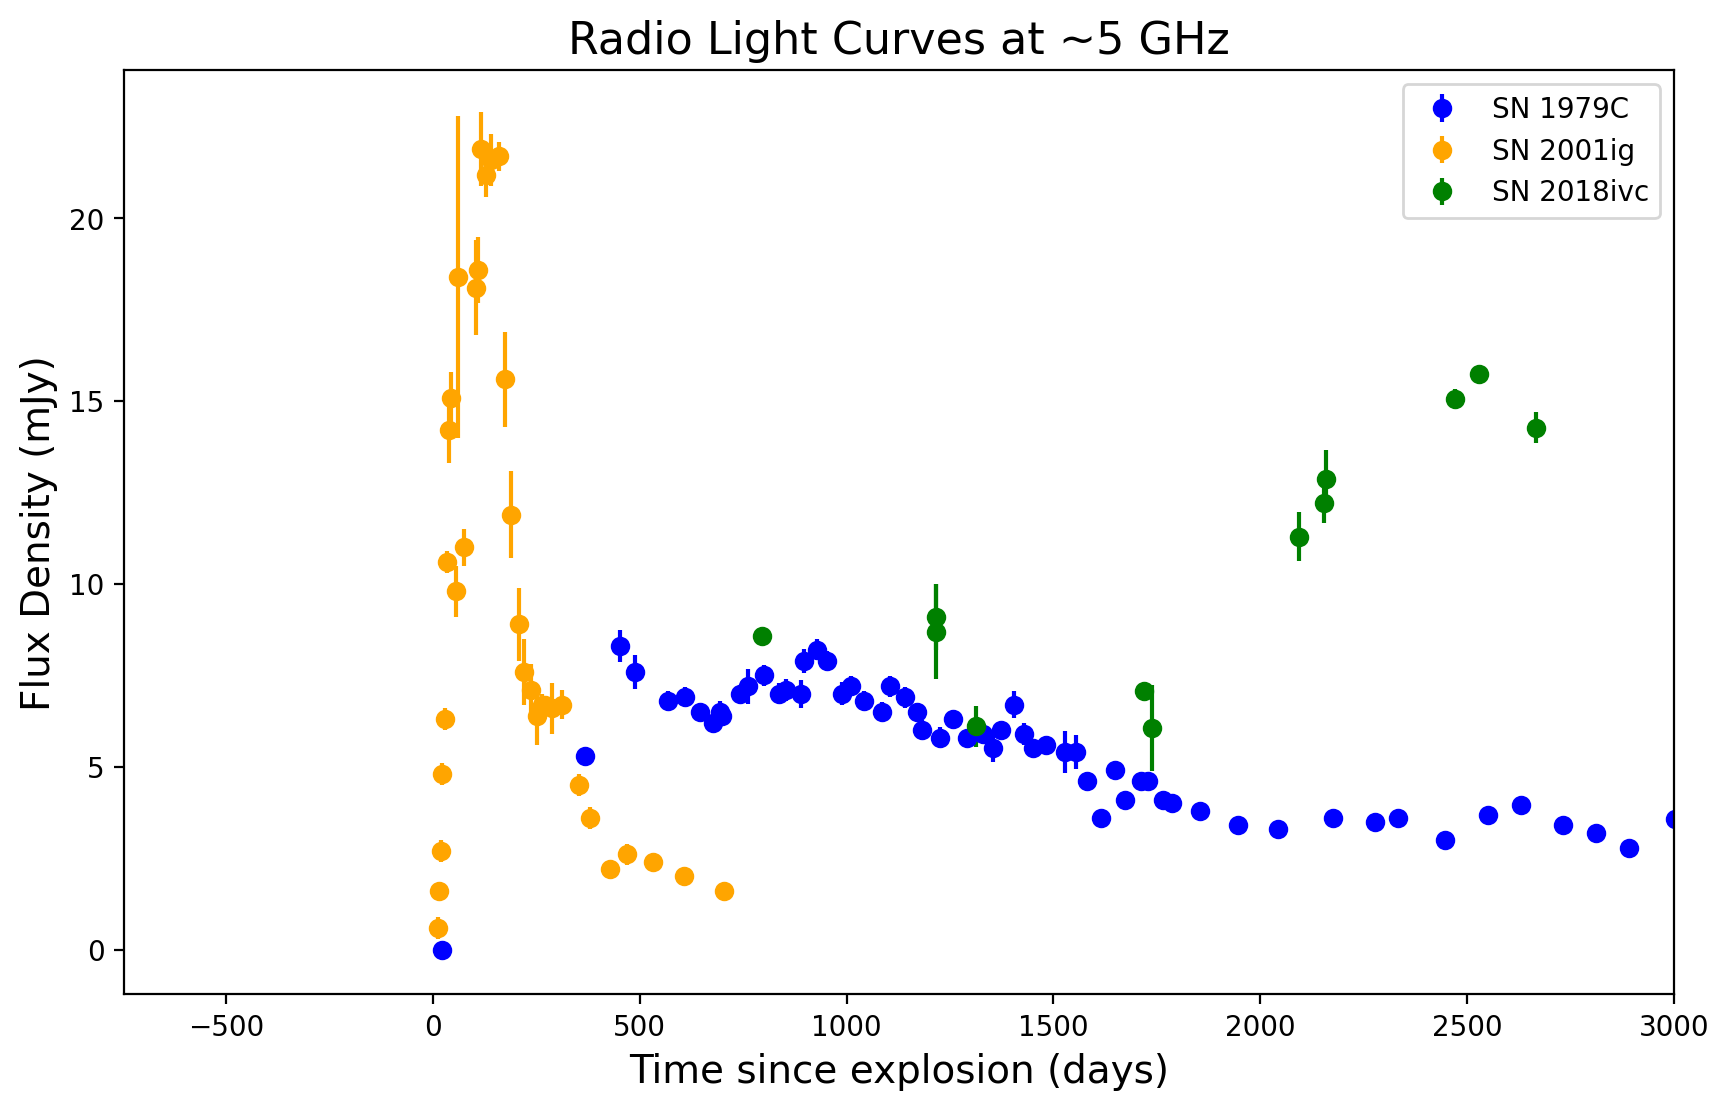

In [39]:
# plot IIL comparison at ~5.0 GHz
SN1979C_5 = SN1979c[((SN1979c['Freq'] > 4.0)&(SN1979c['Freq'] < 7.0))]
SN2001ig_5 = SN2001ig[((SN2001ig['Freq'] > 4.0)&(SN2001ig['Freq'] < 7.0))]
SN2018ivc_5 = SN2018ivc[((SN2018ivc['freq'] > 4.0)&(SN2018ivc['freq'] < 7.0))]

plt.figure(figsize=(10,6), dpi=200)
plt.errorbar(SN1979C_5['Time'], SN1979C_5['Flux (mJy)'], yerr=SN1979C_5['rms'], fmt='o', label='SN 1979C', color='blue')
plt.errorbar(SN2001ig_5['Time'], SN2001ig_5['Flux (mJy)'], yerr=SN2001ig_5['rms'], fmt='o', label='SN 2001ig', color='orange')
plt.errorbar(SN2018ivc_5['phase'], SN2018ivc_5['flux'], yerr=SN2018ivc_5['flux_err'], fmt='o', label='SN 2018ivc', color='green')
plt.xlabel('Time since explosion (days)', fontsize=14)
plt.ylabel('Flux Density (mJy)', fontsize=14)
plt.title('Radio Light Curves at ~5 GHz', fontsize=16)
plt.legend()
plt.xlim(None, 3000)

In [ ]:
# plot IIL comparison at ~22.0 GHz